In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs('../outputs', exist_ok=True)
print("Outputs folder created!")
# Load the dataset
df = pd.read_csv('credit_risk_dataset.csv')

# First look
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Outputs folder created!
Shape: (32581, 12)

Columns: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
# ── Basic exploration ──────────────────────────────────────────
print(f"Total rows    : {df.shape[0]:,}")
print(f"Total columns : {df.shape[1]}")
# Data types
print("\nColumn types:")
print(df.dtypes)

# Missing values
print("\nMissing values:")
missing = df.isnull().sum()
print(missing[missing > 0])

# Target variable distribution
print("\nDefault rate:")
print(df['loan_status'].value_counts())
default_rate = df['loan_status'].mean() * 100
print(f"\n→ {default_rate:.1f}% of loans defaulted")

Total rows    : 32,581
Total columns : 12

Column types:
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

Missing values:
person_emp_length     895
loan_int_rate        3116
dtype: int64

Default rate:
loan_status
0    25473
1     7108
Name: count, dtype: int64

→ 21.8% of loans defaulted


In [5]:
# ── Data Cleaning ──────────────────────────────────────────────
print("Before cleaning:")
print(f"  emp_length missing : {df['person_emp_length'].isnull().sum()}")
print(f"  int_rate missing   : {df['loan_int_rate'].isnull().sum()}")

# Fix 1: Employment length — fill with median (safe for skewed data)
df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)

# Fix 2: Interest rate — fill with median PER LOAN GRADE
# (smarter! A-grade loans shouldn't get same rate as D-grade)
df['loan_int_rate'] = df.groupby('loan_grade')['loan_int_rate']\
                        .transform(lambda x: x.fillna(x.median()))

# Fix 3: Remove impossible ages (data quality check)
print(f"\nAges above 80: {(df['person_age'] > 80).sum()} rows")
df = df[df['person_age'] <= 80]

# Fix 4: Remove impossible income outliers
print(f"Income above 1M: {(df['person_income'] > 1_000_000).sum()} rows")
df = df[df['person_income'] <= 1_000_000]

print("\nAfter cleaning:")
print(f"  Missing values left: {df.isnull().sum().sum()}")
print(f"  Rows remaining     : {df.shape[0]:,}")
print("\n Data is clean!")

Before cleaning:
  emp_length missing : 895
  int_rate missing   : 3116

Ages above 80: 7 rows
Income above 1M: 8 rows

After cleaning:
  Missing values left: 0
  Rows remaining     : 32,566

 Data is clean!


C:\Users\srish\AppData\Local\Temp\ipykernel_1184\3918254295.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)


In [6]:
# ── Feature Engineering ────────────────────────────────────────
# These are the metrics real banks actually use

# 1. Debt-to-Income ratio (DTI) — how burdened is this person?
df['dti_ratio'] = (df['loan_amnt'] / df['person_income']).round(3)

# 2. Income per year of employment — stability indicator
df['income_per_emp_year'] = (df['person_income'] / 
                              (df['person_emp_length'] + 1)).round(0)

# 3. Interest rate tier — how expensive is this loan?
df['rate_tier'] = pd.cut(df['loan_int_rate'],
                          bins=[0, 8, 12, 16, 100],
                          labels=['Low (<8%)', 'Medium (8-12%)',
                                  'High (12-16%)', 'Very High (>16%)'])

# 4. Risk Score (0-100) — our custom scoring model
# Higher score = higher risk
def calculate_risk_score(row):
    score = 0
    # Grade risk (A=0, G=35)
    grade_map = {'A':0,'B':5,'C':12,'D':20,'E':28,'F':32,'G':35}
    score += grade_map.get(row['loan_grade'], 20)
    # DTI risk
    if row['dti_ratio'] > 0.5:   score += 25
    elif row['dti_ratio'] > 0.3: score += 15
    elif row['dti_ratio'] > 0.2: score += 8
    # Prior default
    if row['cb_person_default_on_file'] == 'Y': score += 20
    # Employment stability
    if row['person_emp_length'] < 2:  score += 10
    elif row['person_emp_length'] < 5: score += 5
    return min(score, 100)

df['risk_score'] = df.apply(calculate_risk_score, axis=1)

# 5. Risk Tier — Low / Medium / High
df['risk_tier'] = pd.cut(df['risk_score'],
                          bins=[0, 30, 55, 100],
                          labels=['Low Risk', 'Medium Risk', 'High Risk'])

print("New features created:")
print(df[['dti_ratio','rate_tier','risk_score','risk_tier']].head(8))
print(f"\nRisk tier breakdown:")
print(df['risk_tier'].value_counts())

New features created:
   dti_ratio         rate_tier  risk_score    risk_tier
0      0.593  Very High (>16%)          65    High Risk
1      0.104    Medium (8-12%)           5     Low Risk
2      0.573     High (12-16%)          47  Medium Risk
3      0.534     High (12-16%)          42  Medium Risk
4      0.643     High (12-16%)          57    High Risk
5      0.253         Low (<8%)          13     Low Risk
6      0.454     High (12-16%)          20     Low Risk
7      0.443    Medium (8-12%)          20     Low Risk

Risk tier breakdown:
risk_tier
Low Risk       21467
Medium Risk     6360
High Risk        824
Name: count, dtype: int64


C:\Users\srish\AppData\Local\Temp\ipykernel_1184\581563013.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,2].boxplot([low, high], labels=['Repaid','Defaulted'],


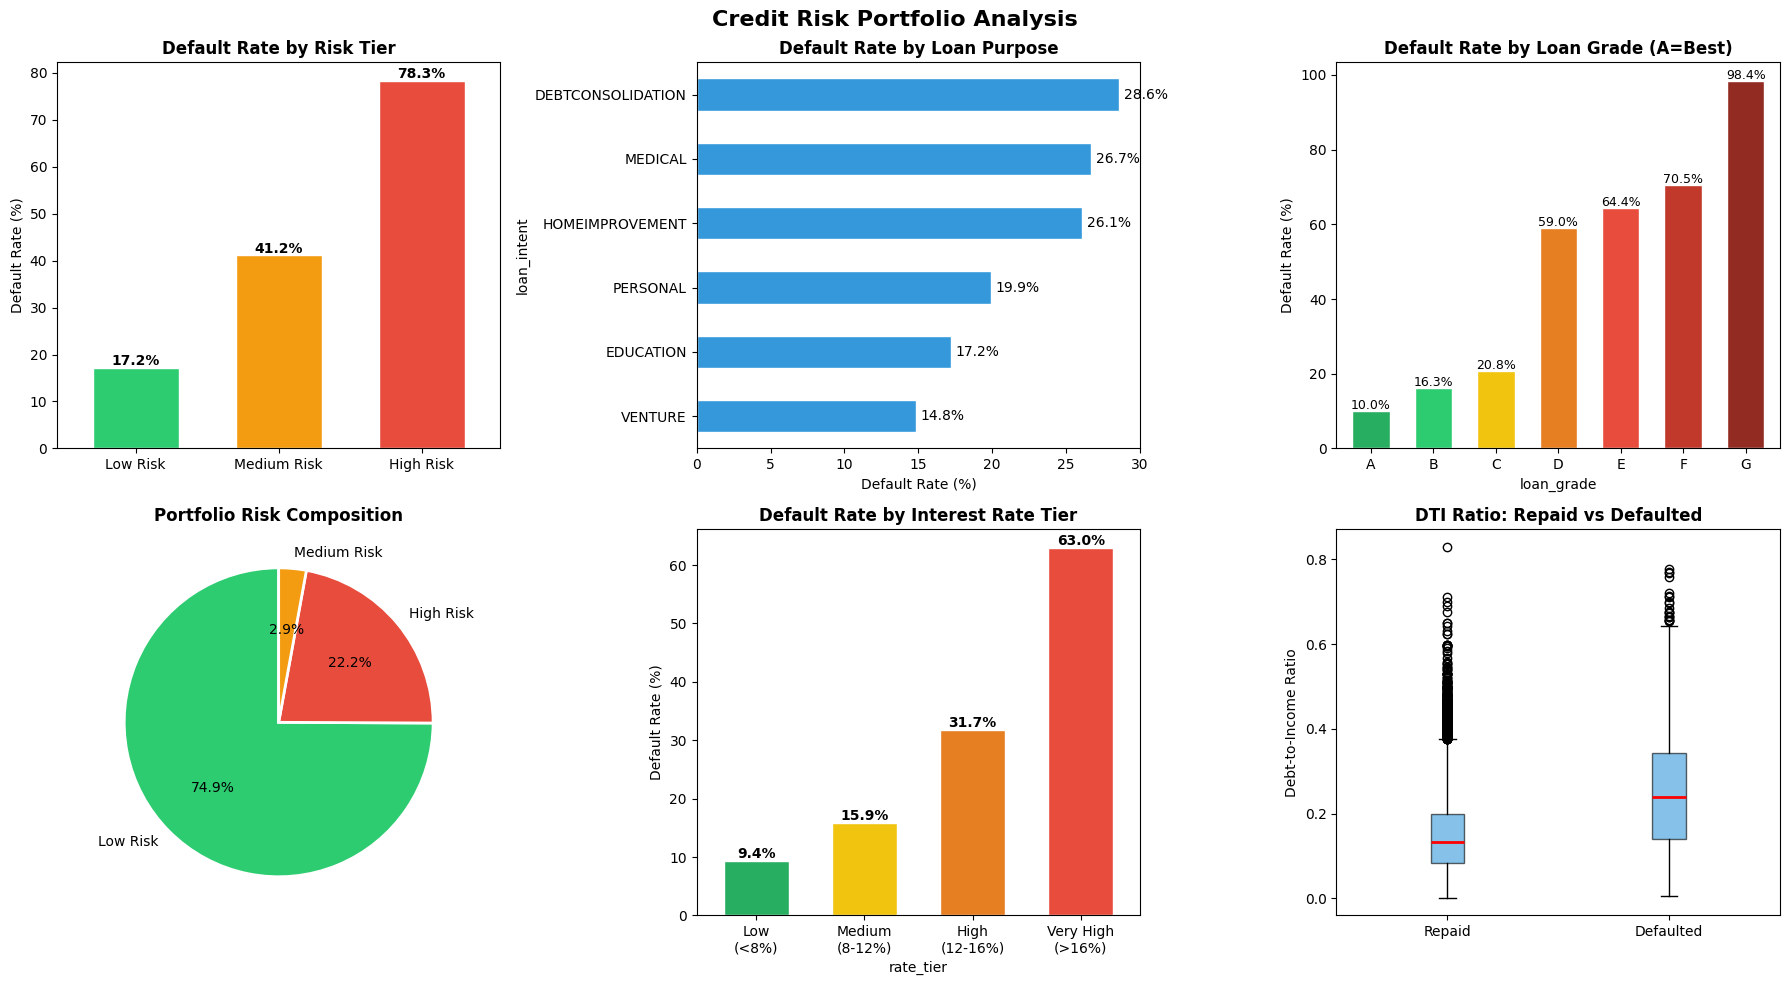

 Analysis chart saved!


In [7]:
# ── Full Portfolio Analysis ─────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Credit Risk Portfolio Analysis', fontsize=16, fontweight='bold')

# ── Chart 1: Default rate by Risk Tier ──
risk_default = df.groupby('risk_tier', observed=True)['loan_status'].mean() * 100
colors_risk = ['#2ecc71', '#f39c12', '#e74c3c']
risk_default.plot(kind='bar', ax=axes[0,0], color=colors_risk, edgecolor='white', width=0.6)
axes[0,0].set_title('Default Rate by Risk Tier', fontweight='bold')
axes[0,0].set_ylabel('Default Rate (%)')
axes[0,0].set_xlabel('')
axes[0,0].set_xticklabels(['Low Risk', 'Medium Risk', 'High Risk'], rotation=0)
for i, v in enumerate(risk_default):
    axes[0,0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# ── Chart 2: Default rate by Loan Intent ──
intent_default = df.groupby('loan_intent')['loan_status'].mean().sort_values(ascending=True) * 100
intent_default.plot(kind='barh', ax=axes[0,1], color='#3498db', edgecolor='white')
axes[0,1].set_title('Default Rate by Loan Purpose', fontweight='bold')
axes[0,1].set_xlabel('Default Rate (%)')
for i, v in enumerate(intent_default):
    axes[0,1].text(v + 0.3, i, f'{v:.1f}%', va='center')

# ── Chart 3: Default rate by Loan Grade ──
grade_default = df.groupby('loan_grade')['loan_status'].mean().sort_index() * 100
grade_colors = ['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c','#c0392b','#922b21']
grade_default.plot(kind='bar', ax=axes[0,2], color=grade_colors, edgecolor='white', width=0.6)
axes[0,2].set_title('Default Rate by Loan Grade (A=Best)', fontweight='bold')
axes[0,2].set_ylabel('Default Rate (%)')
axes[0,2].set_xticklabels(['A','B','C','D','E','F','G'], rotation=0)
for i, v in enumerate(grade_default):
    axes[0,2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

# ── Chart 4: Portfolio composition by Risk Tier ──
tier_counts = df['risk_tier'].value_counts()
axes[1,0].pie(tier_counts, labels=['Low Risk','High Risk','Medium Risk'],
              colors=['#2ecc71','#e74c3c','#f39c12'],
              autopct='%1.1f%%', startangle=90,
              wedgeprops={'edgecolor':'white','linewidth':2})
axes[1,0].set_title('Portfolio Risk Composition', fontweight='bold')

# ── Chart 5: Default rate by Interest Rate Tier ──
rate_default = df.groupby('rate_tier', observed=True)['loan_status'].mean().sort_index() * 100
rate_default.plot(kind='bar', ax=axes[1,1],
                  color=['#27ae60','#f1c40f','#e67e22','#e74c3c'],
                  edgecolor='white', width=0.6)
axes[1,1].set_title('Default Rate by Interest Rate Tier', fontweight='bold')
axes[1,1].set_ylabel('Default Rate (%)')
axes[1,1].set_xticklabels(['Low\n(<8%)','Medium\n(8-12%)','High\n(12-16%)','Very High\n(>16%)'], rotation=0)
for i, v in enumerate(rate_default):
    axes[1,1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# ── Chart 6: DTI vs Default (box plot) ──
low  = df[df['loan_status']==0]['dti_ratio']
high = df[df['loan_status']==1]['dti_ratio']
axes[1,2].boxplot([low, high], labels=['Repaid','Defaulted'],
                  patch_artist=True,
                  boxprops=dict(facecolor='#3498db', alpha=0.6),
                  medianprops=dict(color='red', linewidth=2))
axes[1,2].set_title('DTI Ratio: Repaid vs Defaulted', fontweight='bold')
axes[1,2].set_ylabel('Debt-to-Income Ratio')

plt.tight_layout()
plt.savefig('../outputs/02_portfolio_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Analysis chart saved!")

In [8]:
# ── Business Insights Summary ───────────────────────────────────

print("CREDIT RISK PORTFOLIO — KEY FINDINGS")

total = len(df)
defaults = df['loan_status'].sum()

print(f"\n Portfolio Overview")
print(f"   Total loans   : {total:,}")
print(f"   Total defaults: {defaults:,}")
print(f"   Overall NPA % : {defaults/total*100:.1f}%")

print(f"\n Risk Tier Breakdown")
for tier in ['Low Risk', 'Medium Risk', 'High Risk']:
    subset = df[df['risk_tier'] == tier]
    dr = subset['loan_status'].mean() * 100
    pct = len(subset) / total * 100
    print(f"   {tier:<14}: {len(subset):>6,} loans ({pct:.1f}%) | Default rate: {dr:.1f}%")

print(f"\n Riskiest Loan Purpose")
worst_intent = df.groupby('loan_intent')['loan_status'].mean().idxmax()
worst_rate   = df.groupby('loan_intent')['loan_status'].mean().max() * 100
print(f"   {worst_intent} loans → {worst_rate:.1f}% default rate")

print(f"\n Loan Grade Insight")
grade_dr = df.groupby('loan_grade')['loan_status'].mean() * 100
print(f"   Grade A default rate : {grade_dr['A']:.1f}%")
print(f"   Grade G default rate : {grade_dr['G']:.1f}%")
print(f"   Difference           : {grade_dr['G'] - grade_dr['A']:.1f} percentage points")

print(f"\n DTI Insight")
avg_dti_repaid   = df[df['loan_status']==0]['dti_ratio'].mean()
avg_dti_default  = df[df['loan_status']==1]['dti_ratio'].mean()
print(f"   Avg DTI (repaid)   : {avg_dti_repaid:.3f}")
print(f"   Avg DTI (defaulted): {avg_dti_default:.3f}")
print(f"   Defaulters carry {((avg_dti_default/avg_dti_repaid)-1)*100:.0f}% higher DTI")


print("Insights ready for dashboard & resume!")


CREDIT RISK PORTFOLIO — KEY FINDINGS

 Portfolio Overview
   Total loans   : 32,566
   Total defaults: 7,108
   Overall NPA % : 21.8%

 Risk Tier Breakdown
   Low Risk      : 21,467 loans (65.9%) | Default rate: 17.2%
   Medium Risk   :  6,360 loans (19.5%) | Default rate: 41.2%
   High Risk     :    824 loans (2.5%) | Default rate: 78.3%

 Riskiest Loan Purpose
   DEBTCONSOLIDATION loans → 28.6% default rate

 Loan Grade Insight
   Grade A default rate : 10.0%
   Grade G default rate : 98.4%
   Difference           : 88.5 percentage points

 DTI Insight
   Avg DTI (repaid)   : 0.149
   Avg DTI (defaulted): 0.249
   Defaulters carry 67% higher DTI
Insights ready for dashboard & resume!


In [9]:
# ── Export clean CSV for Power BI ──────────────────────────────
df.to_csv('../outputs/credit_risk_clean.csv', index=False)
print(f" Clean CSV saved! Shape: {df.shape}")

 Clean CSV saved! Shape: (32566, 17)


In [10]:
sql_queries = """
-- CREDIT RISK PORTFOLIO ANALYSIS
-- Author: Srishti | Dataset: 32,581 loans

-- 1. PORTFOLIO OVERVIEW
SELECT
    COUNT(*)                                    AS total_loans,
    SUM(loan_status)                            AS total_defaults,
    ROUND(AVG(loan_status) * 100, 2)           AS default_rate_pct,
    ROUND(AVG(loan_amnt), 0)                   AS avg_loan_amount,
    ROUND(AVG(loan_int_rate), 2)               AS avg_interest_rate
FROM credit_risk;

-- 2. DEFAULT RATE BY LOAN GRADE
SELECT
    loan_grade,
    COUNT(*)                                    AS total_loans,
    SUM(loan_status)                            AS defaults,
    ROUND(AVG(loan_status) * 100, 2)           AS default_rate_pct,
    ROUND(AVG(loan_int_rate), 2)               AS avg_interest_rate
FROM credit_risk
GROUP BY loan_grade
ORDER BY loan_grade;

-- 3. RISK TIER ANALYSIS
SELECT
    risk_tier,
    COUNT(*)                                    AS total_loans,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) 
          OVER(), 1)                            AS portfolio_pct,
    ROUND(AVG(loan_status) * 100, 2)           AS default_rate_pct,
    ROUND(AVG(dti_ratio), 3)                   AS avg_dti,
    ROUND(AVG(loan_amnt), 0)                   AS avg_loan_amount
FROM credit_risk
GROUP BY risk_tier
ORDER BY default_rate_pct;

-- 4. HIGH RISK EARLY WARNING FLAGS
SELECT
    loan_grade,
    loan_intent,
    COUNT(*)                                    AS total_loans,
    ROUND(AVG(loan_status) * 100, 2)           AS default_rate_pct,
    ROUND(AVG(dti_ratio), 3)                   AS avg_dti
FROM credit_risk
WHERE loan_grade IN ('E','F','G')
   OR dti_ratio > 0.4
   OR cb_person_default_on_file = 'Y'
GROUP BY loan_grade, loan_intent
HAVING COUNT(*) > 50
ORDER BY default_rate_pct DESC
LIMIT 10;

-- 5. DEFAULT RATE BY LOAN PURPOSE
SELECT
    loan_intent,
    COUNT(*)                                    AS total_loans,
    SUM(loan_status)                            AS defaults,
    ROUND(AVG(loan_status) * 100, 2)           AS default_rate_pct,
    ROUND(AVG(loan_amnt), 0)                   AS avg_loan_amount
FROM credit_risk
GROUP BY loan_intent
ORDER BY default_rate_pct DESC;

-- 6. INCOME VS DEFAULT SEGMENTATION
SELECT
    CASE
        WHEN person_income < 30000  THEN '1. <30K'
        WHEN person_income < 60000  THEN '2. 30K-60K'
        WHEN person_income < 100000 THEN '3. 60K-100K'
        ELSE                             '4. 100K+'
    END                                         AS income_band,
    COUNT(*)                                    AS total_loans,
    ROUND(AVG(loan_status) * 100, 2)           AS default_rate_pct,
    ROUND(AVG(dti_ratio), 3)                   AS avg_dti
FROM credit_risk
GROUP BY income_band
ORDER BY income_band;

-- 7. PORTFOLIO NPA SUMMARY (for KPI cards)
SELECT
    ROUND(AVG(loan_status) * 100, 2)           AS overall_npa_pct,
    ROUND(AVG(CASE WHEN risk_tier='High Risk'
              THEN loan_status END) * 100, 2)  AS high_risk_npa_pct,
    ROUND(AVG(dti_ratio), 3)                   AS avg_portfolio_dti,
    COUNT(DISTINCT loan_grade)                  AS grade_count,
    ROUND(AVG(loan_int_rate), 2)               AS avg_interest_rate
FROM credit_risk;
"""

# Save SQL file
with open('../outputs/credit_risk_queries.sql', 'w') as f:
    f.write(sql_queries)

print("SQL queries saved to outputs folder!")
print("\nQueries written:")
print("  1. Portfolio overview")
print("  2. Default rate by loan grade")
print("  3. Risk tier analysis")
print("  4. High risk early warning flags")
print("  5. Default rate by loan purpose")
print("  6. Income vs default segmentation")
print("  7. Portfolio NPA summary (KPI cards)")

SQL queries saved to outputs folder!

Queries written:
  1. Portfolio overview
  2. Default rate by loan grade
  3. Risk tier analysis
  4. High risk early warning flags
  5. Default rate by loan purpose
  6. Income vs default segmentation
  7. Portfolio NPA summary (KPI cards)


In [11]:
print(df['risk_tier'].value_counts(dropna=False))

risk_tier
Low Risk       21467
Medium Risk     6360
NaN             3915
High Risk        824
Name: count, dtype: int64


In [12]:
df['risk_tier'] = df['risk_tier'].astype(str)
df.to_csv('../outputs/credit_risk_clean.csv', index=False)
print("✅ Exported!")

✅ Exported!
